In [1]:
import warnings
from pathlib import Path

import cv2
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pyproj
import rasterio
from pyproj import CRS, Geod, Transformer
from rasterio.features import rasterize, shapes
from rasterio.windows import Window, bounds as granice_okna
from shapely.geometry import LineString, Point, Polygon, mapping, shape

plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 11})

ZDJECIE = Path("data/tapias_ortofoto.tif")          # <- tu możesz podstawić własne zdjęcie
KATALOG = Path("results/playground")
KATALOG.mkdir(parents=True, exist_ok=True)

In [2]:
with rasterio.open(ZDJECIE) as src:
    dane = src.read()                      # rasterio: (kanały, wiersze, kolumny)
rgb = np.moveaxis(dane, 0, -1)             # matplotlib / OpenCV / skimage: (wiersze, kolumny, kanały)

print("rasterio:", dane.shape, "→ po moveaxis:", rgb.shape, "| typ:", rgb.dtype)
print("fragment rgb[850:1250, 1000:1400] ma kształt", rgb[850:1250, 1000:1400].shape, " (tak wycinamy FRAGMENT w notebooku 01)")
print("piksel w wierszu 300, kolumnie 500:", rgb[300, 500], "→ R, G, B")

rasterio: (3, 1731, 1731) → po moveaxis: (1731, 1731, 3) | typ: uint8
fragment rgb[850:1250, 1000:1400] ma kształt (400, 400, 3)  (tak wycinamy FRAGMENT w notebooku 01)
piksel w wierszu 300, kolumnie 500: [163 147 113] → R, G, B


typ maski: bool | pikseli True: 1906527 | udział: 63.6%
piksele ważne: 92.4%


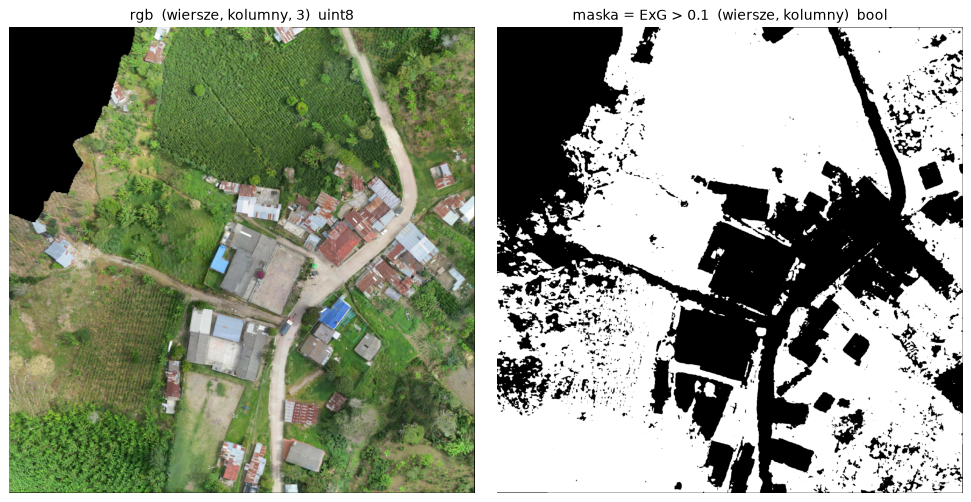

In [3]:
R, G, B = (rgb[..., i].astype(np.float32) for i in range(3))      # float32, żeby nie przekręcić uint8
exg = (2 * G - R - B) / (R + G + B + 1e-6)                          # uproszczony ExG; 1e-6 chroni przed dzieleniem przez 0
PROG_EXG = 0.10                                                     # <- zmień (0.05 … 0.20) i uruchom ponownie

maska = exg > PROG_EXG                                              # tablica bool: True = „roślinność"
waznie = ~(rgb == 0).all(axis=-1)                                   # czarne tło poza ortomozaikiem = brak danych

print("typ maski:", maska.dtype, "| pikseli True:", maska.sum(), f"| udział: {maska.mean():.1%}")
print(f"piksele ważne: {waznie.mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
ax[0].imshow(rgb); ax[0].set_title("rgb  (wiersze, kolumny, 3)  uint8")
ax[1].imshow(maska, cmap="gray"); ax[1].set_title(f"maska = ExG > {PROG_EXG}  (wiersze, kolumny)  bool")
for a_ in ax: a_.axis("off")
plt.tight_layout()

In [6]:
import rasterio

with rasterio.open("data/tapias_ortofoto.tif") as ds:
    print(ds.width, ds.height, ds.count, ds.dtypes[0])  
    print(ds.crs, ds.res)

1731 1731 3 uint8
EPSG:32618 (0.12, 0.12)
